# Corpus breakdown

Simple counts for the final 1,627-script analysis corpus.

In [5]:
import json
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

METADATA_PATH = Path('../Movie-Script-Database/scripts/metadata/analysis_corpus_final.json')
corpus = json.loads(METADATA_PATH.read_text())
print(f'Scripts: {len(corpus)}')

Scripts: 1627


## Decade breakdown

Decade  Count
 1980s    214
 1990s    287
 2000s    310
 2010s    569
 2020s    247


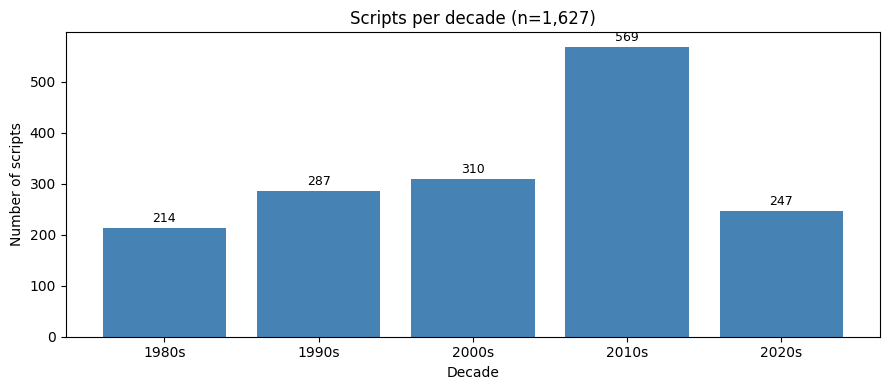

In [6]:
decade_counts = Counter(
    (e['year'] // 10) * 10
    for e in corpus
    if e.get('year')
)

decade_df = (
    pd.Series(decade_counts)
    .sort_index()
    .rename_axis('Decade')
    .reset_index(name='Count')
)
decade_df['Decade'] = decade_df['Decade'].astype(str) + 's'

print(decade_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(decade_df['Decade'], decade_df['Count'], color='steelblue')
ax.set_xlabel('Decade')
ax.set_ylabel('Number of scripts')
ax.set_title('Scripts per decade (n=1,627)')
for bar, count in zip(ax.patches, decade_df['Count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Genre breakdown but with primary genre only

TMDb lists genres in relevance order, so I treat **first genre** as the dominant label. Each script contributes exactly one count, so there is no double-counting.

          Genre  Count  Pct
          Drama    449 27.6
         Comedy    299 18.4
         Action    178 10.9
         Horror    144  8.9
      Adventure    114  7.0
          Crime     86  5.3
       Thriller     72  4.4
Science Fiction     59  3.6
        Fantasy     48  3.0
      Animation     41  2.5
        Romance     35  2.2
        Mystery     24  1.5
        History     22  1.4
         Family     20  1.2
            War     13  0.8
          Music     12  0.7
        Western      9  0.6

No genre listed: 2


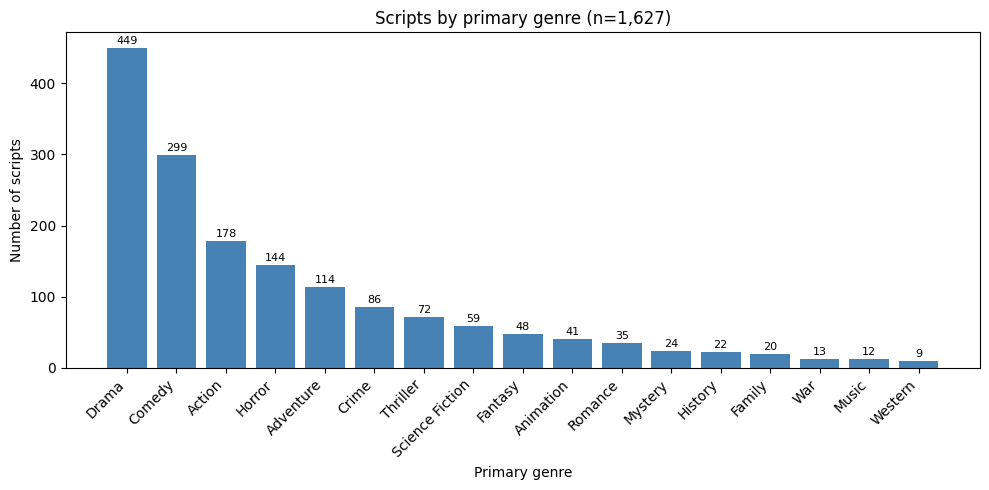

In [10]:
primary_counts = Counter(
    e['tmdb']['genres'][0]
    for e in corpus
    if e.get('tmdb', {}).get('genres')
)
no_genre = sum(1 for e in corpus if not e.get('tmdb', {}).get('genres'))

primary_df = (
    pd.Series(primary_counts)
    .sort_values(ascending=False)
    .rename_axis('Genre')
    .reset_index(name='Count')
)
primary_df['Pct'] = (primary_df['Count'] / len(corpus) * 100).round(1)

print(primary_df.to_string(index=False))
print(f'\nNo genre listed: {no_genre}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(primary_df['Genre'], primary_df['Count'], color='steelblue')
ax.set_xlabel('Primary genre')
ax.set_ylabel('Number of scripts')
ax.set_title('Scripts by primary genre (n=1,627)')
plt.xticks(rotation=45, ha='right')
for bar, count in zip(ax.patches, primary_df['Count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            str(count), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## Genre co-occurrence, so % of corpus carrying each tag

Shows how often each genre tag appears across all scripts (multi-label). Useful context: a high Drama % means Drama is frequently *paired* with other genres, not that the corpus is dominated by pure dramas.

          Genre  Scripts with tag  % of corpus
          Drama               848         52.1
         Comedy               532         32.7
       Thriller               421         25.9
         Action               355         21.8
          Crime               278         17.1
      Adventure               274         16.8
        Romance               233         14.3
Science Fiction               227         14.0
         Horror               216         13.3
        Fantasy               171         10.5
        Mystery               163         10.0
        History               131          8.1
         Family               104          6.4
      Animation                62          3.8
          Music                49          3.0
            War                45          2.8
        Western                22          1.4
    Documentary                 1          0.1


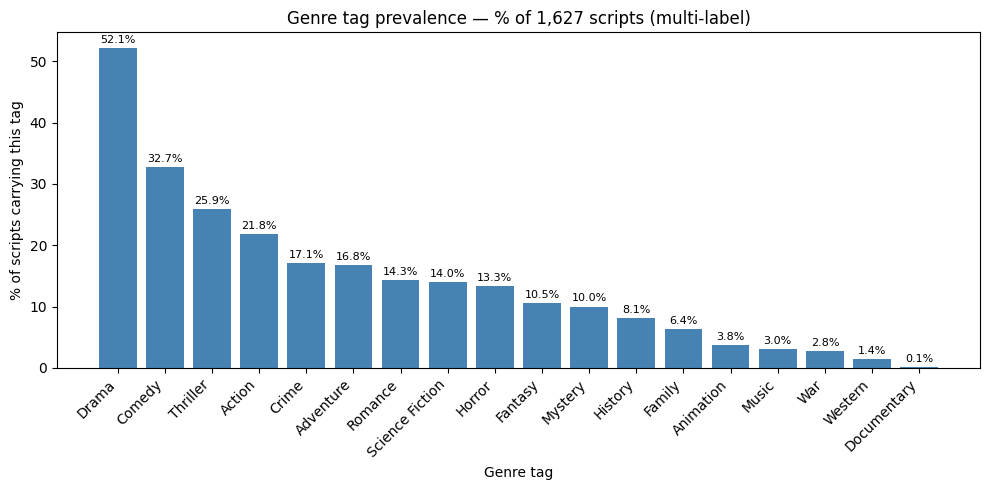

In [9]:
all_genre_counts = Counter(
    g
    for e in corpus
    for g in e.get('tmdb', {}).get('genres', [])
)

pct_df = (
    pd.Series(all_genre_counts)
    .sort_values(ascending=False)
    .rename_axis('Genre')
    .reset_index(name='Scripts with tag')
)
pct_df['% of corpus'] = (pct_df['Scripts with tag'] / len(corpus) * 100).round(1)

print(pct_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pct_df['Genre'], pct_df['% of corpus'], color='steelblue')
ax.set_xlabel('Genre tag')
ax.set_ylabel('% of scripts carrying this tag')
ax.set_title('Genre tag prevalence — % of 1,627 scripts (multi-label)')
plt.xticks(rotation=45, ha='right')
for bar, pct in zip(ax.patches, pct_df['% of corpus']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{pct}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## Primary genre × decade heatmap

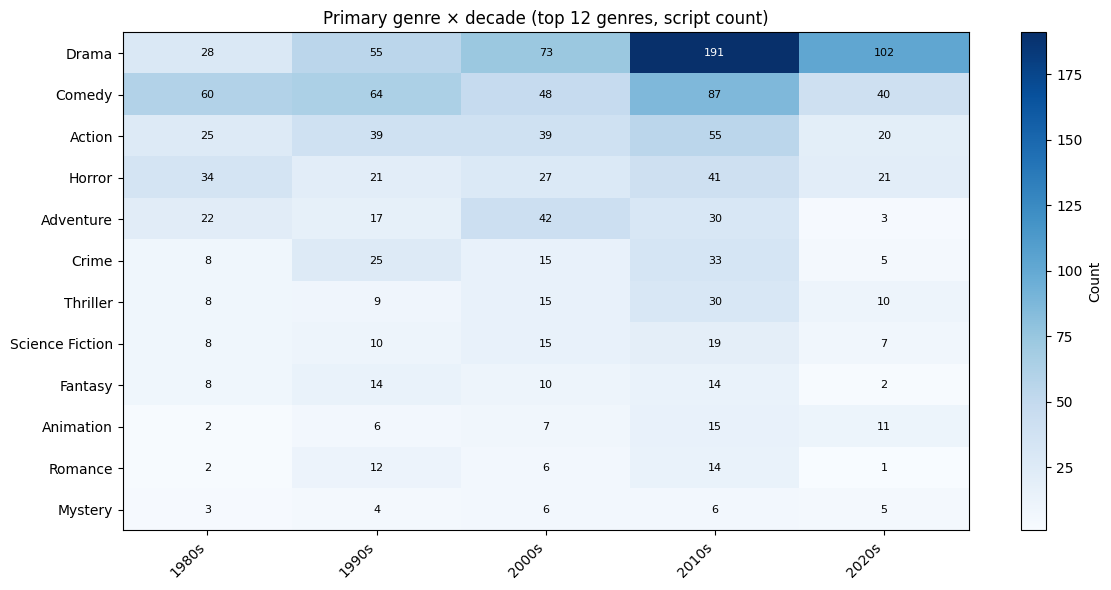

In [11]:
rows = [
    {
        'Decade': str((e['year'] // 10) * 10) + 's',
        'Genre':  e['tmdb']['genres'][0],
    }
    for e in corpus
    if e.get('year') and e.get('tmdb', {}).get('genres')
]

cross = (
    pd.DataFrame(rows)
    .groupby(['Genre', 'Decade'])
    .size()
    .unstack(fill_value=0)
)

# Top 12 primary genres for readability
top_genres = primary_df['Genre'].head(12).tolist()
cross = cross.loc[cross.index.isin(top_genres)].loc[top_genres]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(cross.values, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(cross.columns)))
ax.set_xticklabels(cross.columns, rotation=45, ha='right')
ax.set_yticks(range(len(cross.index)))
ax.set_yticklabels(cross.index)
ax.set_title('Primary genre × decade (top 12 genres, script count)')
for i in range(len(cross.index)):
    for j in range(len(cross.columns)):
        v = cross.values[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=8,
                    color='white' if v > cross.values.max() * 0.6 else 'black')
plt.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.show()